In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset
df = pd.read_excel("/content/superstore_sales.xlsx")

In [ ]:
# Display first 10 rows
df.head(10)

,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Base Margin,Ship Date
0,3,2010-10-13,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,0.80,2010-10-20
1,293,2012-10-01,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,0.58,2012-10-02
2,293,2012-10-01,High,27,244.5700,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,0.39,2012-10-03
3,483,2011-07-10,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,3.99,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,0.58,2011-07-12
4,515,2010-08-28,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,5.94,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,0.50,2010-08-30
5,515,2010-08-28,Not Specified,21,146.6900,0.05,Regular Air,4.43,6.64,4.95,Carlos Soltero,Nunavut,Nunavut,Consumer,Furniture,Office Furnishings,0.37,2010-08-30
6,613,2011-06-17,High,12,93.5400,0.03,Regular Air,-54.04,7.30,7.72,Carl Jackson,Nunavut,Nunavut,Corporate,Office Supplies,Binders and Binder Accessories,0.38,2011-06-17
7,613,2011-06-17,High,22,905.0800,0.09,Regular Air,127.70,42.76,6.22,Carl Jackson,Nunavut,Nunavut,Corporate,Office Supplies,Storage & Organization,NaN,2011-06-18
8,643,2011-03-24,High,21,2781.8200,0.07,Express Air,-695.26,138.14,35.00,Monica Federle,Nunavut,Nunavut,Corporate,Office Supplies,Storage & Organization,NaN,2011-03-25
9,678,2010-02-26,Low,44,228.4100,0.07,Regular Air,-226.36,4.98,8.33,Dorothy Badders,Nunavut,Nunavut,Home Office,Office Supplies,Paper,0.38,2010-02-26


In [ ]:
# dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order ID              8399 non-null   int64         
 1   Order Date            8399 non-null   datetime64[ns]
 2   Order Priority        8399 non-null   object        
 3   Order Quantity        8399 non-null   int64         
 4   Sales                 8399 non-null   float64       
 5   Discount              8399 non-null   float64       
 6   Ship Mode             8399 non-null   object        
 7   Profit                8399 non-null   float64       
 8   Unit Price            8399 non-null   float64       
 9   Shipping Cost         8399 non-null   float64       
 10  Customer Name         8399 non-null   object        
 11  Province              8399 non-null   object        
 12  Region                8399 non-null   object        
 13  Customer Segment  

In [ ]:
df.describe()

,Order ID,Order Date,Order Quantity,Sales,Discount,Profit,Unit Price,Shipping Cost,Product Base Margin,Ship Date
count,8399.000000,8399,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8336.000000,8399
mean,29965.179783,2010-12-25 00:40:58.578402048,25.571735,1775.878179,0.049671,181.184424,89.346259,12.838557,0.512513,2010-12-27 01:28:48.634361088
min,3.000000,2009-01-01 00:00:00,1.000000,2.240000,0.000000,-14140.700000,0.990000,0.490000,0.350000,2009-01-02 00:00:00
25%,15011.500000,2009-12-20 00:00:00,13.000000,143.195000,0.020000,-83.315000,6.480000,3.300000,0.380000,2009-12-22 12:00:00
50%,29857.000000,2010-12-17 00:00:00,26.000000,449.420000,0.050000,-1.500000,20.990000,6.070000,0.520000,2010-12-18 00:00:00
75%,44596.000000,2012-01-01 12:00:00,38.000000,1709.320000,0.080000,162.750000,85.990000,13.990000,0.590000,2012-01-03 12:00:00
max,59973.000000,2012-12-30 00:00:00,50.000000,89061.050000,0.250000,27220.690000,6783.020000,164.730000,0.850000,2012-12-30 00:00:00
std,17260.883447,NaN,14.481071,3585.050525,0.031823,1196.653371,290.354383,17.264052,0.135589,NaN


**Data Cleaning**

In [ ]:
# cheacking missing values
df.isnull().sum()

,0
Order ID,0
Order Date,0
Order Priority,0
Order Quantity,0
Sales,0
Discount,0
Ship Mode,0
Profit,0
Unit Price,0
Shipping Cost,0


In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [ ]:
# convert Order date to datetime
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

**Exploratory Data Analysis (EDA)**

In [ ]:
#Total Sales and Profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)

Total Sales: 14915600.824000001
Total Profit: 1521767.98


In [ ]:
#To checking Columns
print(df.columns)

Index(['Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales',
       'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost',
       'Customer Name', 'Province', 'Region', 'Customer Segment',
       'Product Category', 'Product Sub-Category', 'Product Base Margin',
       'Ship Date'],
      dtype='object')


In [ ]:
# To make Index all columns
df.columns=df.columns.str.strip()
print(df.columns)

Index(['Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales',
       'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost',
       'Customer Name', 'Province', 'Region', 'Customer Segment',
       'Product Category', 'Product Sub-Category', 'Product Base Margin',
       'Ship Date'],
      dtype='object')


In [ ]:
sales_by_category=df.groupby('Product Category')['Sales'].sum()
print(sales_by_category)
print(type(sales_by_category))

Product Category
Furniture          5178590.542
Office Supplies    3752762.100
Technology         5984248.182
Name: Sales, dtype: float64
<class 'pandas.core.series.Series'>


# **Sales by Product Category**

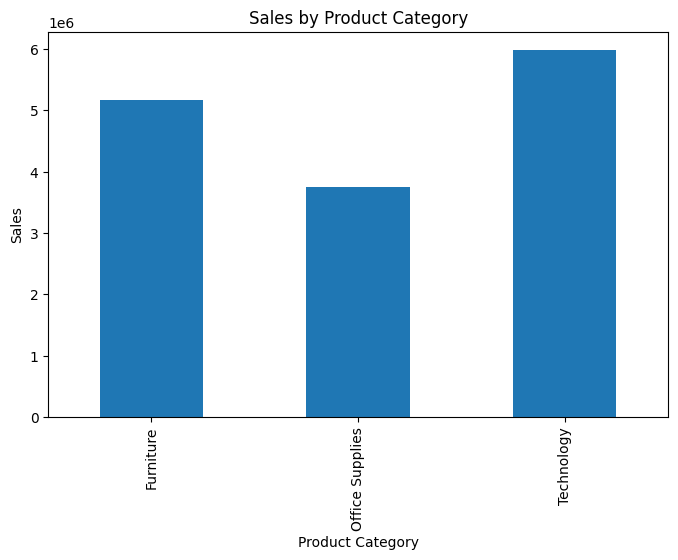

In [ ]:
plt.figure(figsize=(8,5))
sales_by_category.plot(kind='bar')
plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.show()

In [ ]:
# To make list
print(df.columns.tolist())

['Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales', 'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost', 'Customer Name', 'Province', 'Region', 'Customer Segment', 'Product Category', 'Product Sub-Category', 'Product Base Margin', 'Ship Date']


In [ ]:
## To make Index all columns
df.columns=df.columns.str.strip()
print(df.columns)

Index(['Order ID', 'Order Date', 'Order Priority', 'Order Quantity', 'Sales',
       'Discount', 'Ship Mode', 'Profit', 'Unit Price', 'Shipping Cost',
       'Customer Name', 'Province', 'Region', 'Customer Segment',
       'Product Category', 'Product Sub-Category', 'Product Base Margin',
       'Ship Date'],
      dtype='object')


# **Profit by Product Category**

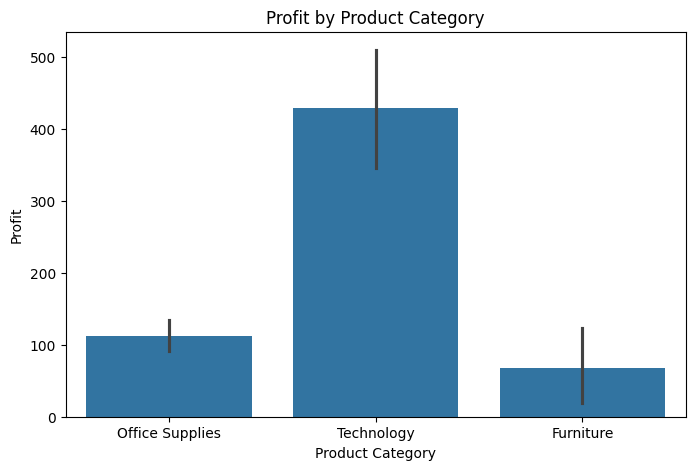

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Product Category',y='Profit', data=df)
plt.title('Profit by Product Category')
plt.show()

# **Sales Trend Over Time**

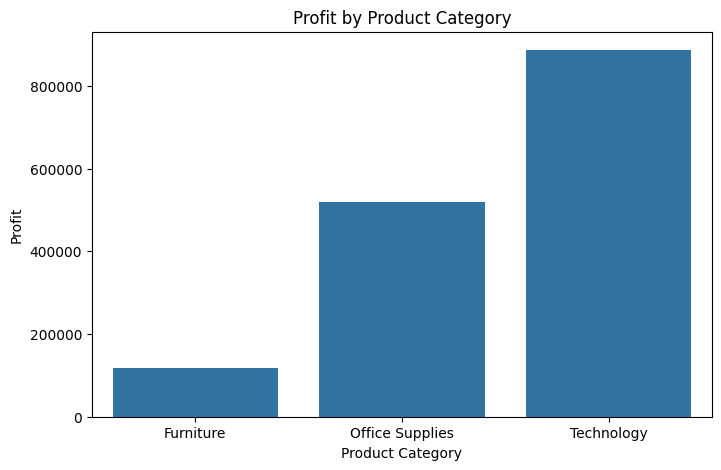

In [158]:
profit_by_category=(df.groupby('Product Category',as_index=False)['Profit'].sum())
plt.figure(figsize=(8,5))
sns.barplot(x='Product Category',y='Profit', data=profit_by_category)
plt.title('Profit by Product Category')
plt.show()

In [161]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period("M"))
['Sales'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

AttributeError: 'list' object has no attribute 'sum'

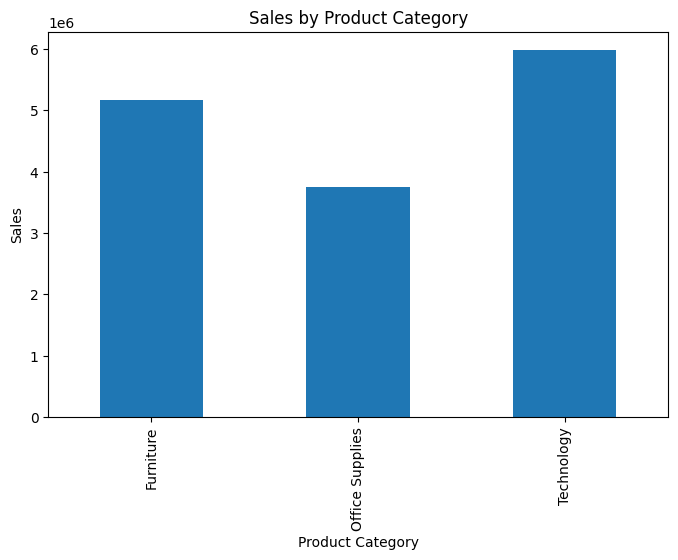

In [162]:
plt.figure(figsize=(8,5))

sales_by_category = df.groupby('Product Category')['Sales'].sum()

sales_by_category.plot(kind='bar')

plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel("Sales")
plt.show()

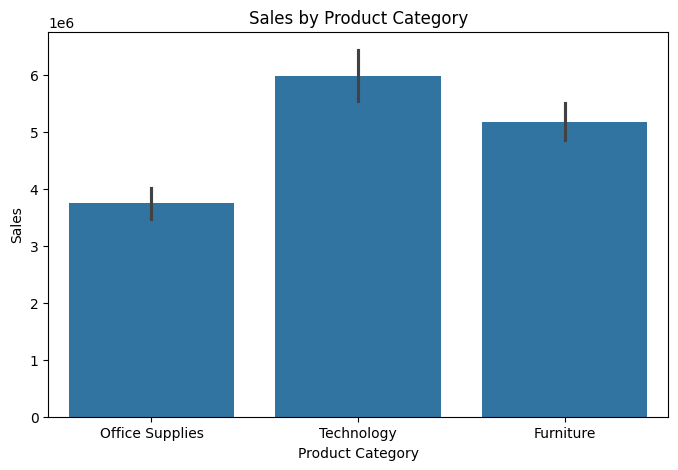

In [163]:
plt.figure(figsize=(8,5))
sns.barplot(x='Product Category', y ='Sales', data=df, estimator= sum)
plt.title('Sales by Product Category')
plt.show()

# **Top 10 Sub-Categories by Sales**

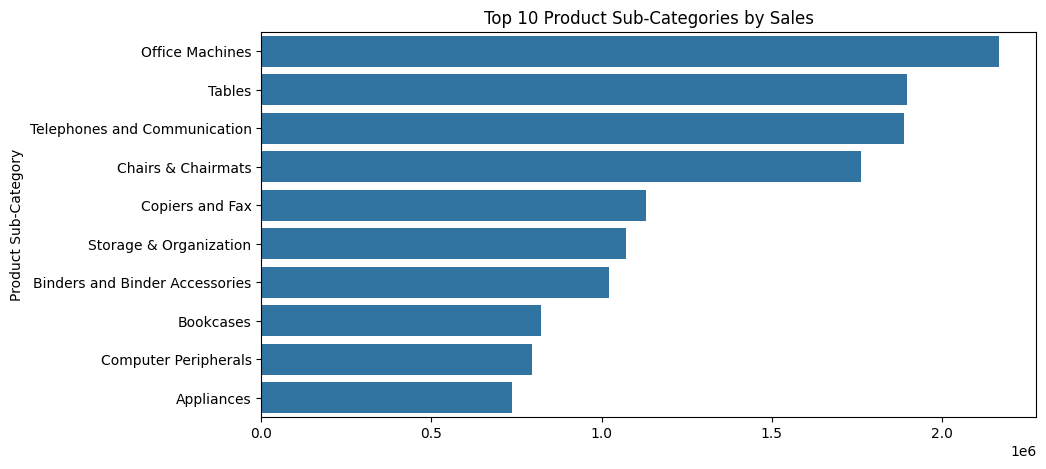

In [153]:
top_sub =df.groupby('Product Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_sub.values, y=top_sub.index)
plt.title('Top 10 Product Sub-Categories by Sales')
plt.show()

# **Region wise analysis**

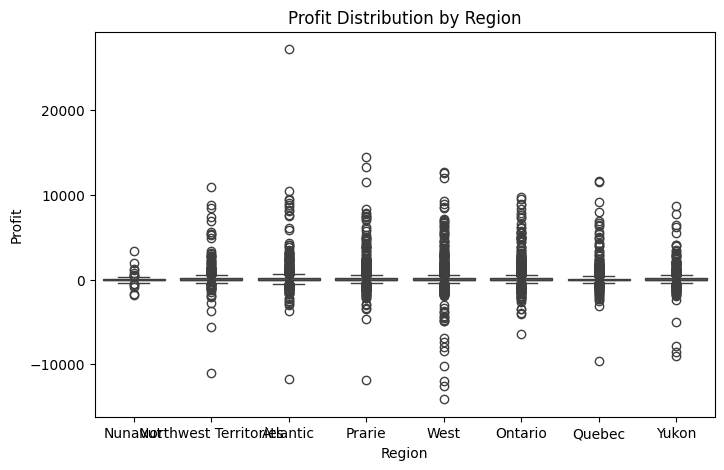

In [155]:
plt.figure(figsize=(8,5))
sns.boxplot(x= 'Region', y='Profit', data=df)
plt.title('Profit Distribution by Region')
plt.show()

# **Correlation Analysis**

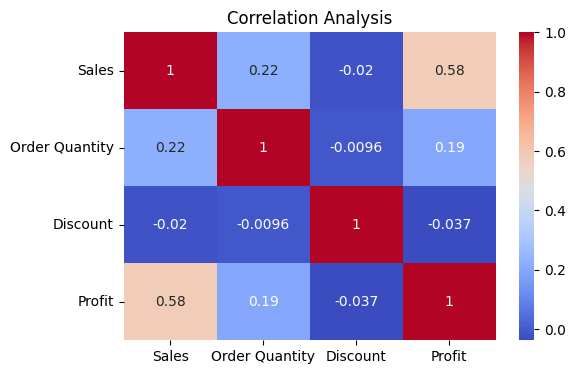

In [156]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Sales','Order Quantity', 'Discount','Profit']].corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Analysis')
plt.show()

# **Business Insights**

In [157]:
print("Most Profitable Category:", df.groupby('Product Category')['Profit'].sum().idxmax())
print("Least Profitable Category:",df.groupby('Product Category')['Profit'].sum().idxmin())

Most Profitable Category: Technology
Least Profitable Category: Furniture
